# Strategy Backtest: U.S. Session Signal to Japan Session Returns

This notebook tests whether U.S. equity market returns can be used as a tradable signal for the next Japanese equity session.

Main setup:
- Signal: S&P 500 open-to-close return from the previous U.S. session
- Target: Nikkei 225 open-to-close return during the next Japanese session
- Models: OLS regression trained on the first 70% of observations
- Evaluation: out-of-sample strategy performance with transaction costs

This notebook should run from top to bottom on a fresh kernel.

## Imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## Configuration

In [2]:
TICKERS = {
    "nikkei": "^N225",
    "sp500": "^GSPC",
}

START_DATE = "2010-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")
TRAIN_SPLIT = 0.70
BASE_COST_BPS = 5

TICKERS, START_DATE, END_DATE

({'nikkei': '^N225', 'sp500': '^GSPC'}, '2010-01-01', '2026-05-26')

## Data Download

In [3]:
raw = yf.download(
    list(TICKERS.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

raw.head()

Price             Close                       High                        Low  \
Ticker            ^GSPC         ^N225        ^GSPC         ^N225        ^GSPC   
2010-01-04 1,132.989990 10,654.790039 1,133.869995 10,694.490234 1,116.560059   
2010-01-05 1,136.520020 10,681.830078 1,136.630005 10,791.040039 1,129.660034   
2010-01-06 1,137.140015 10,731.450195 1,139.189941 10,768.610352 1,133.949951   
2010-01-07 1,141.689941 10,681.660156 1,142.459961 10,774.000000 1,131.319946   
2010-01-08 1,144.979980 10,798.320312 1,145.390015 10,816.450195 1,136.219971   

Price                            Open                             Volume  \
Ticker             ^N225        ^GSPC         ^N225                ^GSPC   
2010-01-04 10,608.139648 1,116.560059 10,609.339844 3,991,400,000.000000   
2010-01-05 10,655.570312 1,132.660034 10,719.440430 2,491,020,000.000000   
2010-01-06 10,661.169922 1,135.709961 10,709.549805 4,972,660,000.000000   
2010-01-07 10,636.669922 1,136.270020 10,742.750000 5,270,680,000.000000   
2010-01-08 10,677.559570 1,140.520020 10,743.299805 4,389,590,000.000000   

Price                          
Ticker                  ^N225  
2010-01-04 104,400,000.000000  
2010-01-05 166,200,000.000000  
2010-01-06 181,800,000.000000  
2010-01-07 182,600,000.000000  
2010-01-08 211,800,000.000000

In [4]:
open_prices = raw["Open"].rename(columns={
    "^N225": "nikkei",
    "^GSPC": "sp500",
})

close_prices = raw["Close"].rename(columns={
    "^N225": "nikkei",
    "^GSPC": "sp500",
})

open_prices.head(), close_prices.head()

(Ticker            sp500        nikkei
 2010-01-04 1,116.560059 10,609.339844
 2010-01-05 1,132.660034 10,719.440430
 2010-01-06 1,135.709961 10,709.549805
 2010-01-07 1,136.270020 10,742.750000
 2010-01-08 1,140.520020 10,743.299805,
 Ticker            sp500        nikkei
 2010-01-04 1,132.989990 10,654.790039
 2010-01-05 1,136.520020 10,681.830078
 2010-01-06 1,137.140015 10,731.450195
 2010-01-07 1,141.689941 10,681.660156
 2010-01-08 1,144.979980 10,798.320312)

## Build Tradable Dataset

We use open-to-close returns for both markets:

- U.S. open-to-close return measures the regular U.S. session move.
- Japan open-to-close return measures the tradable Japanese session after the U.S. signal is known.

`merge_asof(..., allow_exact_matches=False)` ensures Japan's session is matched with the most recent prior U.S. session, not a same-timestamp row.

In [5]:
sp500_open_to_close = (close_prices["sp500"] / open_prices["sp500"] - 1).dropna()
nikkei_open_to_close = (close_prices["nikkei"] / open_prices["nikkei"] - 1).dropna()

us_signal = sp500_open_to_close.reset_index()
us_signal.columns = ["us_date", "feature_sp500_open_to_close"]

jp_target = nikkei_open_to_close.reset_index()
jp_target.columns = ["japan_date", "target_nikkei_open_to_close"]

japan_tradable = pd.merge_asof(
    jp_target.sort_values("japan_date"),
    us_signal.sort_values("us_date"),
    left_on="japan_date",
    right_on="us_date",
    direction="backward",
    allow_exact_matches=False,
).dropna()

japan_tradable.head()

,japan_date,target_nikkei_open_to_close,us_date,feature_sp500_open_to_close
1,2010-01-05,-0.003509,2010-01-04,0.014715
2,2010-01-06,0.002045,2010-01-05,0.003408
3,2010-01-07,-0.005687,2010-01-06,0.001259
4,2010-01-08,0.005121,2010-01-07,0.004770
5,2010-01-12,0.010101,2010-01-11,0.000890


In [6]:
japan_tradable[["feature_sp500_open_to_close", "target_nikkei_open_to_close"]].describe()

,feature_sp500_open_to_close,target_nikkei_open_to_close
count,"4,005.000000","4,005.000000"
mean,0.000332,-0.000008
std,0.009112,0.009510
min,-0.065934,-0.107546
25%,-0.003302,-0.004396
50%,0.000554,-0.000041
75%,0.004861,0.004730
max,0.099012,0.080996


## Helper Functions

In [7]:
def regression_summary(df, feature_col, target_col):
    X = sm.add_constant(df[feature_col])
    y = df[target_col]
    model = sm.OLS(y, X).fit()

    return pd.Series({
        "coefficient": model.params[feature_col],
        "p_value": model.pvalues[feature_col],
        "r_squared": model.rsquared,
        "observations": int(model.nobs),
    })


def performance_stats(returns_series, periods_per_year=252):
    r = returns_series.dropna()
    equity = (1 + r).cumprod()

    total_return = equity.iloc[-1] - 1
    annual_return = equity.iloc[-1] ** (periods_per_year / len(r)) - 1
    annual_volatility = r.std() * np.sqrt(periods_per_year)
    sharpe = annual_return / annual_volatility if annual_volatility != 0 else np.nan
    max_drawdown = (equity / equity.cummax() - 1).min()

    return pd.Series({
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate": (r > 0).mean(),
    })


def build_signals(predicted_return, mode="long_only", threshold=0.0):
    if mode == "long_only":
        return np.where(predicted_return > threshold, 1, 0)

    if mode == "long_short":
        return np.where(predicted_return > threshold, 1, -1)

    if mode == "threshold_long_only":
        return np.where(predicted_return > threshold, 1, 0)

    if mode == "threshold_long_short":
        return np.select(
            [predicted_return > threshold, predicted_return < -threshold],
            [1, -1],
            default=0,
        )

    raise ValueError(f"Unknown mode: {mode}")


def backtest_signal_strategy(
    df,
    feature_col,
    target_col,
    date_col,
    mode="long_only",
    threshold=0.0,
    split=0.70,
    cost_bps=5,
):
    df = df.copy().sort_values(date_col)
    split_idx = int(len(df) * split)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:].copy()

    X_train = sm.add_constant(train[feature_col])
    y_train = train[target_col]
    model = sm.OLS(y_train, X_train).fit()

    X_test = sm.add_constant(test[feature_col])
    test["predicted_return"] = model.predict(X_test)
    test["signal"] = build_signals(test["predicted_return"], mode=mode, threshold=threshold)

    test["turnover"] = test["signal"].diff().abs()
    test.loc[test.index[0], "turnover"] = abs(test.loc[test.index[0], "signal"])

    test["cost"] = test["turnover"] * (cost_bps / 10000)
    test["strategy_return"] = test["signal"] * test[target_col] - test["cost"]
    test["buy_hold_return"] = test[target_col]

    return test, model


def yearly_performance(bt, date_col, strategy_col="strategy_return", benchmark_col="buy_hold_return"):
    yearly = bt.copy()
    yearly["year"] = pd.to_datetime(yearly[date_col]).dt.year

    rows = []
    for year, group in yearly.groupby("year"):
        strategy_stats = performance_stats(group[strategy_col])
        benchmark_stats = performance_stats(group[benchmark_col])

        rows.append({
            "year": year,
            "strategy_return": strategy_stats["total_return"],
            "benchmark_return": benchmark_stats["total_return"],
            "strategy_sharpe": strategy_stats["sharpe"],
            "benchmark_sharpe": benchmark_stats["sharpe"],
            "strategy_max_drawdown": strategy_stats["max_drawdown"],
            "benchmark_max_drawdown": benchmark_stats["max_drawdown"],
        })

    return pd.DataFrame(rows)

## Baseline Regression

In [8]:
regression_summary(
    japan_tradable,
    "feature_sp500_open_to_close",
    "target_nikkei_open_to_close",
)

coefficient        0.120154
p_value            0.000000
r_squared          0.013253
observations   4,005.000000
dtype: float64

## Strategy Variants

We compare several implementations of the same signal:

- Long-only: long Japan when predicted return is positive, otherwise cash
- Long-short: long Japan when predicted return is positive, short Japan otherwise
- Threshold long-only: trade only when predicted return exceeds a threshold
- Threshold long-short: long strong positive predictions, short strong negative predictions, otherwise cash

In [9]:
strategy_specs = [
    ("Long Only", "long_only", 0.0),
    ("Long Short", "long_short", 0.0),
    ("Threshold Long Only 5bps", "threshold_long_only", 0.0005),
    ("Threshold Long Short 5bps", "threshold_long_short", 0.0005),
    ("Threshold Long Only 10bps", "threshold_long_only", 0.0010),
    ("Threshold Long Short 10bps", "threshold_long_short", 0.0010),
]

backtests = {}
variant_results = {}

for name, mode, threshold in strategy_specs:
    bt, model = backtest_signal_strategy(
        japan_tradable,
        feature_col="feature_sp500_open_to_close",
        target_col="target_nikkei_open_to_close",
        date_col="japan_date",
        mode=mode,
        threshold=threshold,
        split=TRAIN_SPLIT,
        cost_bps=BASE_COST_BPS,
    )
    backtests[name] = bt
    variant_results[name] = performance_stats(bt["strategy_return"])

variant_results["Buy & Hold"] = performance_stats(bt["buy_hold_return"])

strategy_variant_results = pd.DataFrame(variant_results).T
strategy_variant_results.sort_values("sharpe", ascending=False)

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
Threshold Long Short 10bps,0.651546,0.110915,0.063650,1.742582,-0.021384,0.045757
Threshold Long Short 5bps,0.823583,0.134235,0.087190,1.539581,-0.067252,0.147255
Threshold Long Only 10bps,0.262618,0.050103,0.044144,1.134983,-0.010967,0.014975
Threshold Long Only 5bps,0.327407,0.061177,0.055432,1.103642,-0.031727,0.051581
Long Only,0.381843,0.070156,0.103691,0.676587,-0.133831,0.211314
Long Short,0.515361,0.091052,0.155773,0.584514,-0.207048,0.490849
Buy & Hold,0.181569,0.035598,0.156205,0.227891,-0.288640,0.496672


## Transaction Cost Sensitivity

In [10]:
cost_results = {}

for cost_bps in [0, 2.5, 5, 10, 20, 50]:
    bt_cost, _ = backtest_signal_strategy(
        japan_tradable,
        feature_col="feature_sp500_open_to_close",
        target_col="target_nikkei_open_to_close",
        date_col="japan_date",
        mode="long_only",
        threshold=0.0,
        split=TRAIN_SPLIT,
        cost_bps=cost_bps,
    )
    cost_results[f"{cost_bps:g} bps"] = performance_stats(bt_cost["strategy_return"])

pd.DataFrame(cost_results).T

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
0 bps,0.840920,0.136488,0.103796,1.314959,-0.113179,0.220466
2.5 bps,0.594977,0.102828,0.103725,0.991349,-0.123565,0.216306
5 bps,0.381843,0.070156,0.103691,0.676587,-0.133831,0.211314
10 bps,0.037098,0.007666,0.103738,0.073899,-0.182405,0.207155
20 bps,-0.416077,-0.106661,0.104286,-1.022775,-0.486677,0.197171
50 bps,-0.896137,-0.377986,0.109418,-3.454517,-0.900437,0.165557


## Equity Curve And Drawdown

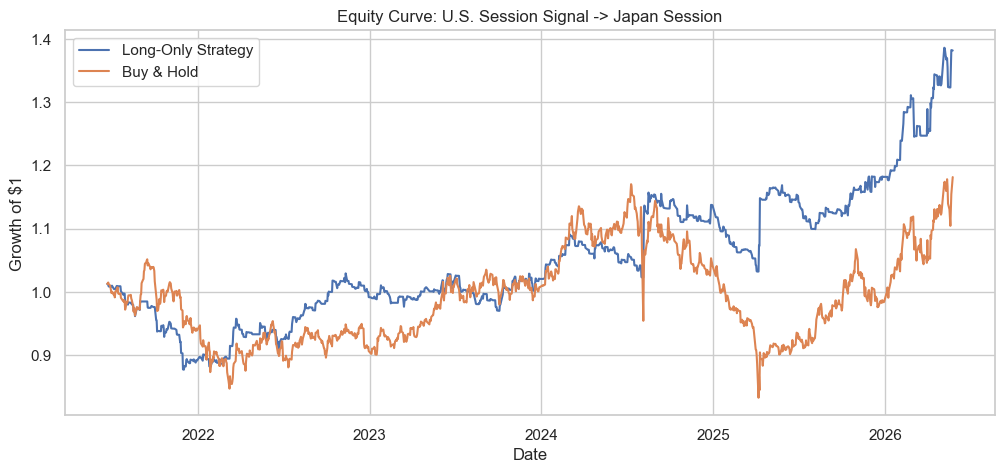

In [11]:
main_bt = backtests["Long Only"].copy()
main_bt["strategy_equity"] = (1 + main_bt["strategy_return"]).cumprod()
main_bt["buy_hold_equity"] = (1 + main_bt["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(main_bt["japan_date"], main_bt["strategy_equity"], label="Long-Only Strategy")
plt.plot(main_bt["japan_date"], main_bt["buy_hold_equity"], label="Buy & Hold")
plt.title("Equity Curve: U.S. Session Signal -> Japan Session")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

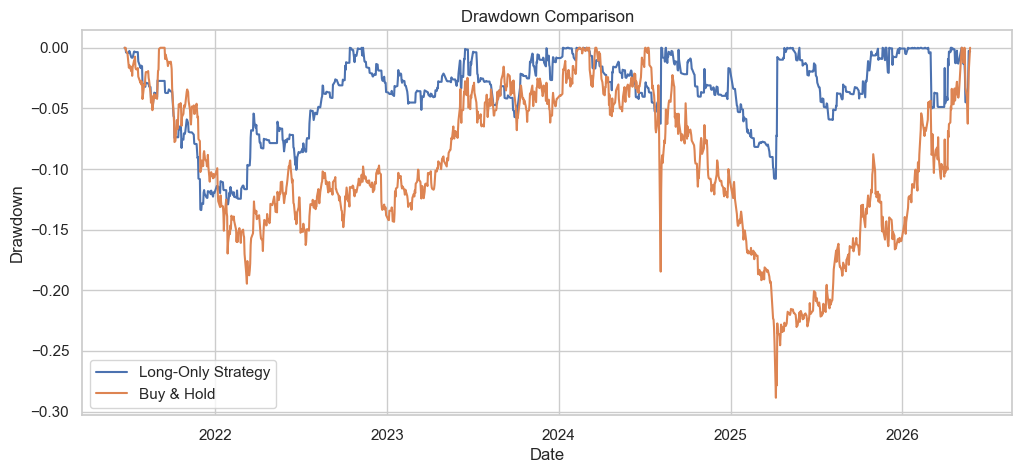

In [12]:
main_bt["strategy_drawdown"] = main_bt["strategy_equity"] / main_bt["strategy_equity"].cummax() - 1
main_bt["buy_hold_drawdown"] = main_bt["buy_hold_equity"] / main_bt["buy_hold_equity"].cummax() - 1

plt.figure(figsize=(12, 5))
plt.plot(main_bt["japan_date"], main_bt["strategy_drawdown"], label="Long-Only Strategy")
plt.plot(main_bt["japan_date"], main_bt["buy_hold_drawdown"], label="Buy & Hold")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

## Yearly Performance

In [13]:
yearly = yearly_performance(main_bt, "japan_date")
yearly

,year,strategy_return,benchmark_return,strategy_sharpe,benchmark_sharpe,strategy_max_drawdown,benchmark_max_drawdown
0,2021,-0.108710,-0.060867,-2.209864,-0.962507,-0.133831,-0.110456
1,2022,0.112633,-0.034898,1.477449,-0.279204,-0.049068,-0.105755
2,2023,0.029070,0.111610,0.415564,1.073795,-0.056599,-0.053230
3,2024,0.114299,0.034154,1.026234,0.176504,-0.062565,-0.184615
4,2025,0.039372,-0.055454,0.366899,-0.348314,-0.077112,-0.200142
5,2026,0.169151,0.200598,3.033104,2.970385,-0.050198,-0.067431


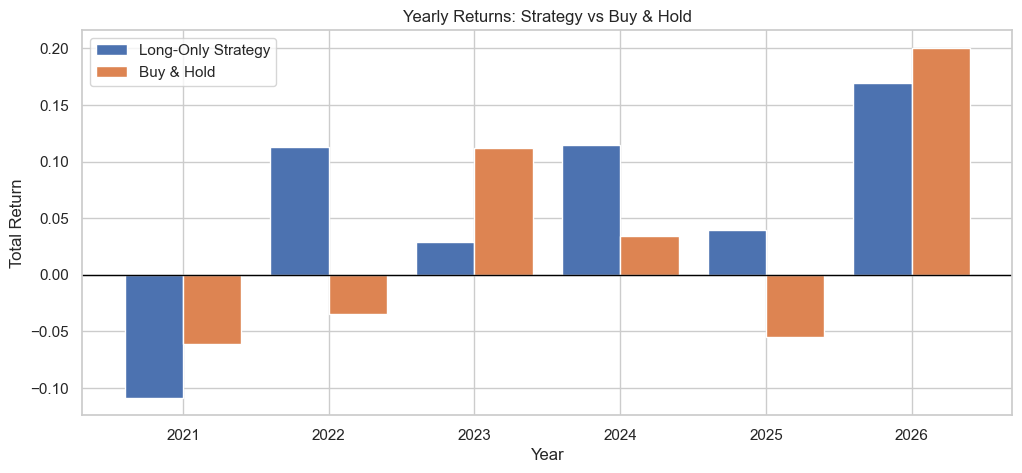

In [14]:
plt.figure(figsize=(12, 5))
plt.bar(yearly["year"] - 0.2, yearly["strategy_return"], width=0.4, label="Long-Only Strategy")
plt.bar(yearly["year"] + 0.2, yearly["benchmark_return"], width=0.4, label="Buy & Hold")
plt.axhline(0, color="black", linewidth=1)
plt.title("Yearly Returns: Strategy vs Buy & Hold")
plt.xlabel("Year")
plt.ylabel("Total Return")
plt.legend()
plt.show()

## Strategy Diagnostics

Threshold strategies may look strong because they trade only on a small number of days. We measure exposure, number of trades, average turnover, and win rate only on invested days.

In [15]:
def strategy_diagnostics(bt):
    bt = bt.copy()
    invested = bt["signal"] != 0
    traded = bt["turnover"] > 0

    invested_returns = bt.loc[invested, "strategy_return"]

    return pd.Series({
        "days": len(bt),
        "invested_days": invested.sum(),
        "exposure": invested.mean(),
        "long_days": (bt["signal"] == 1).sum(),
        "short_days": (bt["signal"] == -1).sum(),
        "cash_days": (bt["signal"] == 0).sum(),
        "num_trades": traded.sum(),
        "avg_daily_turnover": bt["turnover"].mean(),
        "invested_win_rate": (invested_returns > 0).mean(),
        "avg_invested_return": invested_returns.mean(),
        "median_invested_return": invested_returns.median(),
        "best_day": bt["strategy_return"].max(),
        "worst_day": bt["strategy_return"].min(),
    })

diagnostics = pd.DataFrame({
    name: strategy_diagnostics(bt)
    for name, bt in backtests.items()
}).T

diagnostics

,days,invested_days,exposure,long_days,short_days,cash_days,num_trades,avg_daily_turnover,invested_win_rate,avg_invested_return,median_invested_return,best_day,worst_day
Long Only,"1,202.000000",508.000000,0.422629,508.000000,0.000000,694.000000,574.000000,0.477537,0.500000,0.000969,0.000014,0.080496,-0.029659
Long Short,"1,202.000000","1,202.000000",1.000000,508.000000,694.000000,0.000000,574.000000,0.954243,0.490849,0.000393,-0.000121,0.107546,-0.029659
Threshold Long Only 5bps,"1,202.000000",111.000000,0.092346,111.000000,0.000000,"1,091.000000",178.000000,0.148087,0.558559,0.003017,0.001411,0.070283,-0.012714
Threshold Long Short 5bps,"1,202.000000",326.000000,0.271215,111.000000,215.000000,876.000000,435.000000,0.412646,0.542945,0.002185,0.001073,0.069783,-0.025697
Threshold Long Only 10bps,"1,202.000000",25.000000,0.020799,25.000000,0.000000,"1,177.000000",42.000000,0.034942,0.720000,0.009928,0.006184,0.070283,-0.009977
Threshold Long Short 10bps,"1,202.000000",82.000000,0.068220,25.000000,57.000000,"1,120.000000",134.000000,0.118136,0.670732,0.006618,0.003904,0.069783,-0.012603


In [16]:
best_bt = backtests["Threshold Long Short 10bps"].copy()

best_bt[["japan_date", "us_date", "feature_sp500_open_to_close", 
         "predicted_return", "signal", "target_nikkei_open_to_close", 
         "strategy_return", "cost"]].query("signal != 0").head(20)

,japan_date,us_date,feature_sp500_open_to_close,predicted_return,signal,target_nikkei_open_to_close,strategy_return,cost
2870,2021-09-29,2021-09-28,-0.015140,-0.001052,-1,-0.002284,0.001784,0.000500
2872,2021-10-01,2021-09-30,-0.014444,-0.001009,-1,-0.015873,0.015373,0.000500
2911,2021-11-29,2021-11-26,-0.015009,-0.001044,-1,-0.001907,0.001407,0.000500
2913,2021-12-01,2021-11-30,-0.015786,-0.001092,-1,0.002472,-0.002972,0.000500
2914,2021-12-02,2021-12-01,-0.019505,-0.001323,-1,0.001341,-0.001341,0.000000
2937,2022-01-06,2022-01-05,-0.018256,-0.001245,-1,-0.022270,0.021770,0.000500
2942,2022-01-14,2022-01-13,-0.015745,-0.001089,-1,-0.004344,0.003844,0.000500
2948,2022-01-24,2022-01-21,-0.016424,-0.001131,-1,0.012103,-0.012603,0.000500
2953,2022-01-31,2022-01-28,0.022061,0.001255,1,0.011666,0.011166,0.000500
2954,2022-02-01,2022-01-31,0.018900,0.001059,1,-0.003264,-0.003264,0.000000


## Train / Validation / Test Evaluation

The previous strategy table compares many variants on one out-of-sample period. That is useful for exploration, but it can overstate results if we choose the best variant after seeing the same test set.

To reduce data snooping, we use a three-way split:

- Train: fit the regression model
- Validation: select the strategy rule and threshold
- Test: evaluate the selected strategy once on untouched data

In [17]:
def train_validation_test_split(df, date_col="japan_date", train_size=0.60, validation_size=0.20):
    df = df.copy().sort_values(date_col)

    train_end = int(len(df) * train_size)
    validation_end = int(len(df) * (train_size + validation_size))

    train = df.iloc[:train_end].copy()
    validation = df.iloc[train_end:validation_end].copy()
    test = df.iloc[validation_end:].copy()

    return train, validation, test


def fit_ols_model(train, feature_col, target_col):
    X_train = sm.add_constant(train[feature_col])
    y_train = train[target_col]
    return sm.OLS(y_train, X_train).fit()


def apply_strategy(model, df, feature_col, target_col, date_col, mode, threshold, cost_bps=5):
    out = df.copy().sort_values(date_col)

    X = sm.add_constant(out[feature_col])
    out["predicted_return"] = model.predict(X)
    out["signal"] = build_signals(out["predicted_return"], mode=mode, threshold=threshold)

    out["turnover"] = out["signal"].diff().abs()
    out.loc[out.index[0], "turnover"] = abs(out.loc[out.index[0], "signal"])

    out["cost"] = out["turnover"] * (cost_bps / 10000)
    out["strategy_return"] = out["signal"] * out[target_col] - out["cost"]
    out["buy_hold_return"] = out[target_col]

    return out

In [18]:
train, validation, test = train_validation_test_split(japan_tradable)

model_tvt = fit_ols_model(
    train,
    feature_col="feature_sp500_open_to_close",
    target_col="target_nikkei_open_to_close",
)

split_summary = pd.DataFrame({
    "start": [train["japan_date"].min(), validation["japan_date"].min(), test["japan_date"].min()],
    "end": [train["japan_date"].max(), validation["japan_date"].max(), test["japan_date"].max()],
    "rows": [len(train), len(validation), len(test)],
}, index=["train", "validation", "test"])

split_summary

,start,end,rows
train,2010-01-05,2019-10-28,2403
validation,2019-10-29,2023-02-09,801
test,2023-02-10,2026-05-25,801


In [19]:
candidate_specs = [
    ("Long Only", "long_only", 0.0),
    ("Long Short", "long_short", 0.0),
    ("Threshold Long Only 5bps", "threshold_long_only", 0.0005),
    ("Threshold Long Short 5bps", "threshold_long_short", 0.0005),
    ("Threshold Long Only 10bps", "threshold_long_only", 0.0010),
    ("Threshold Long Short 10bps", "threshold_long_short", 0.0010),
]

validation_backtests = {}
validation_results = {}

for name, mode, threshold in candidate_specs:
    bt_val = apply_strategy(
        model_tvt,
        validation,
        feature_col="feature_sp500_open_to_close",
        target_col="target_nikkei_open_to_close",
        date_col="japan_date",
        mode=mode,
        threshold=threshold,
        cost_bps=BASE_COST_BPS,
    )
    validation_backtests[name] = bt_val
    validation_results[name] = performance_stats(bt_val["strategy_return"])

validation_results = pd.DataFrame(validation_results).T.sort_values("sharpe", ascending=False)
validation_results

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
Threshold Long Short 5bps,0.192332,0.056903,0.117798,0.483055,-0.149314,0.243446
Threshold Long Only 5bps,0.051956,0.016063,0.075523,0.212687,-0.129834,0.107366
Threshold Long Only 10bps,0.027860,0.008683,0.058191,0.149209,-0.105503,0.033708
Threshold Long Short 10bps,0.045093,0.013973,0.094356,0.148085,-0.153754,0.098627
Long Only,-0.100094,-0.032636,0.098246,-0.332181,-0.213937,0.223471
Long Short,-0.147968,-0.049130,0.145463,-0.337751,-0.372284,0.479401


In [20]:
best_name = validation_results.index[0]
best_spec = [spec for spec in candidate_specs if spec[0] == best_name][0]
_, best_mode, best_threshold = best_spec

best_name, best_mode, best_threshold

('Threshold Long Short 5bps', 'threshold_long_short', 0.0005)

In [21]:
bt_test = apply_strategy(
    model_tvt,
    test,
    feature_col="feature_sp500_open_to_close",
    target_col="target_nikkei_open_to_close",
    date_col="japan_date",
    mode=best_mode,
    threshold=best_threshold,
    cost_bps=BASE_COST_BPS,
)

test_results = pd.DataFrame({
    f"Selected Strategy: {best_name}": performance_stats(bt_test["strategy_return"]),
    "Buy & Hold": performance_stats(bt_test["buy_hold_return"]),
}).T

test_results

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
Selected Strategy: Threshold Long Short 5bps,0.717238,0.185439,0.118316,1.567317,-0.083869,0.166042
Buy & Hold,0.272523,0.078769,0.170156,0.462924,-0.288640,0.491885


In [22]:
pd.DataFrame({
    f"Selected Strategy: {best_name}": strategy_diagnostics(bt_test),
}).T

,days,invested_days,exposure,long_days,short_days,cash_days,num_trades,avg_daily_turnover,invested_win_rate,avg_invested_return,median_invested_return,best_day,worst_day
Selected Strategy: Threshold Long Short 5bps,801.000000,251.000000,0.313358,89.000000,162.000000,550.000000,359.000000,0.501873,0.529880,0.002556,0.000997,0.107546,-0.025697


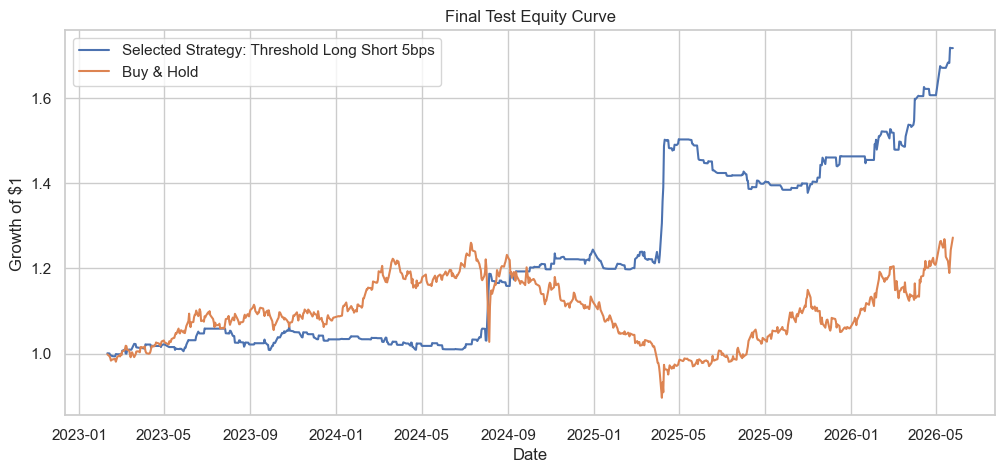

In [23]:
bt_test = bt_test.copy()
bt_test["strategy_equity"] = (1 + bt_test["strategy_return"]).cumprod()
bt_test["buy_hold_equity"] = (1 + bt_test["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(bt_test["japan_date"], bt_test["strategy_equity"], label=f"Selected Strategy: {best_name}")
plt.plot(bt_test["japan_date"], bt_test["buy_hold_equity"], label="Buy & Hold")
plt.title("Final Test Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## Walk-Forward Backtest

A fixed train/validation/test split is useful, but it still depends on one historical partition. A walk-forward backtest is closer to how a strategy would be researched through time:

1. Train the model using only past data.
2. Select the best strategy variant on a recent validation window.
3. Refit the model using all data available before the next test window.
4. Trade the next out-of-sample window.
5. Move forward and repeat.

This section tests whether the strategy selection process is stable across time rather than dependent on one lucky split.

In [24]:
def walk_forward_backtest(
    df,
    feature_col,
    target_col,
    date_col,
    candidate_specs,
    initial_train_size=1500,
    validation_size=250,
    test_size=63,
    cost_bps=5,
):
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    fold_outputs = []
    fold_summaries = []

    test_start = initial_train_size + validation_size
    fold_id = 1

    while test_start < len(df):
        validation_start = test_start - validation_size
        test_end = min(test_start + test_size, len(df))

        train_fold = df.iloc[:validation_start].copy()
        validation_fold = df.iloc[validation_start:test_start].copy()
        test_fold = df.iloc[test_start:test_end].copy()

        if len(train_fold) < 30 or len(validation_fold) == 0 or len(test_fold) == 0:
            break

        selection_model = fit_ols_model(train_fold, feature_col, target_col)

        validation_tables = {}
        for name, mode, threshold in candidate_specs:
            bt_val = apply_strategy(
                selection_model,
                validation_fold,
                feature_col=feature_col,
                target_col=target_col,
                date_col=date_col,
                mode=mode,
                threshold=threshold,
                cost_bps=cost_bps,
            )
            validation_tables[name] = performance_stats(bt_val["strategy_return"])

        validation_table = pd.DataFrame(validation_tables).T
        selected_name = validation_table["sharpe"].fillna(-np.inf).idxmax()
        selected_mode, selected_threshold = [
            (mode, threshold)
            for name, mode, threshold in candidate_specs
            if name == selected_name
        ][0]

        live_model = fit_ols_model(
            pd.concat([train_fold, validation_fold], axis=0),
            feature_col,
            target_col,
        )

        live = test_fold.copy().sort_values(date_col)
        X_live = sm.add_constant(live[feature_col])
        live["predicted_return"] = live_model.predict(X_live)
        live["signal"] = build_signals(
            live["predicted_return"],
            mode=selected_mode,
            threshold=selected_threshold,
        )
        live["fold"] = fold_id
        live["selected_strategy"] = selected_name
        live["selected_threshold"] = selected_threshold
        live["gross_strategy_return"] = live["signal"] * live[target_col]
        live["buy_hold_return"] = live[target_col]

        fold_outputs.append(live)
        fold_summaries.append({
            "fold": fold_id,
            "train_start": train_fold[date_col].min(),
            "train_end": train_fold[date_col].max(),
            "validation_start": validation_fold[date_col].min(),
            "validation_end": validation_fold[date_col].max(),
            "test_start": test_fold[date_col].min(),
            "test_end": test_fold[date_col].max(),
            "selected_strategy": selected_name,
            "validation_sharpe": validation_table.loc[selected_name, "sharpe"],
            "validation_total_return": validation_table.loc[selected_name, "total_return"],
            "model_coefficient": live_model.params[feature_col],
            "model_r_squared_train_validation": live_model.rsquared,
            "test_rows": len(test_fold),
        })

        test_start = test_end
        fold_id += 1

    if not fold_outputs:
        raise ValueError("No walk-forward folds were generated. Reduce the window sizes.")

    results = pd.concat(fold_outputs, axis=0).sort_values(date_col).reset_index(drop=True)
    results["turnover"] = results["signal"].diff().abs()
    results.loc[results.index[0], "turnover"] = abs(results.loc[results.index[0], "signal"])
    results["cost"] = results["turnover"] * (cost_bps / 10000)
    results["strategy_return"] = results["gross_strategy_return"] - results["cost"]

    folds = pd.DataFrame(fold_summaries)
    return results, folds


In [25]:
wf_results, wf_folds = walk_forward_backtest(
    japan_tradable,
    feature_col="feature_sp500_open_to_close",
    target_col="target_nikkei_open_to_close",
    date_col="japan_date",
    candidate_specs=candidate_specs,
    initial_train_size=1500,
    validation_size=250,
    test_size=63,
    cost_bps=BASE_COST_BPS,
)

wf_folds.head()

,fold,train_start,train_end,validation_start,validation_end,test_start,test_end,selected_strategy,validation_sharpe,validation_total_return,model_coefficient,model_r_squared_train_validation,test_rows
0,1,2010-01-05,2016-02-18,2016-02-19,2017-02-24,2017-02-27,2017-05-30,Threshold Long Only 10bps,0.821321,0.017464,0.076395,0.004840,63
1,2,2010-01-05,2016-05-24,2016-05-25,2017-05-30,2017-05-31,2017-08-29,Threshold Long Only 5bps,-0.367678,-0.036807,0.076711,0.004873,63
2,3,2010-01-05,2016-08-23,2016-08-24,2017-08-29,2017-08-30,2017-11-30,Threshold Long Only 5bps,0.941306,0.044363,0.076594,0.004860,63
3,4,2010-01-05,2016-11-25,2016-11-28,2017-11-30,2017-12-01,2018-03-06,Threshold Long Only 5bps,0.882989,0.003886,0.075081,0.004630,63
4,5,2010-01-05,2017-02-28,2017-03-01,2018-03-06,2018-03-07,2018-06-07,Threshold Long Short 10bps,1.471995,0.057421,0.081457,0.005560,63


In [26]:
wf_summary = pd.DataFrame({
    "Walk-Forward Selected Strategy": performance_stats(wf_results["strategy_return"]),
    "Buy & Hold": performance_stats(wf_results["buy_hold_return"]),
}).T

wf_summary

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
Walk-Forward Selected Strategy,0.494086,0.045892,0.081854,0.560652,-0.145517,0.075831
Buy & Hold,0.173966,0.018085,0.143889,0.125689,-0.288640,0.497561


In [27]:
wf_selection_counts = wf_folds["selected_strategy"].value_counts().rename_axis("strategy").to_frame("folds_selected")
wf_selection_counts

,folds_selected
strategy,
Threshold Long Short 10bps,16
Threshold Long Only 5bps,9
Threshold Long Only 10bps,6
Threshold Long Short 5bps,5


In [28]:
pd.DataFrame({
    "Walk-Forward Selected Strategy": strategy_diagnostics(wf_results),
}).T

,days,invested_days,exposure,long_days,short_days,cash_days,num_trades,avg_daily_turnover,invested_win_rate,avg_invested_return,median_invested_return,best_day,worst_day
Walk-Forward Selected Strategy,"2,255.000000",334.000000,0.148115,144.000000,190.000000,"1,921.000000",463.000000,0.237694,0.511976,0.001583,0.000465,0.069783,-0.051460


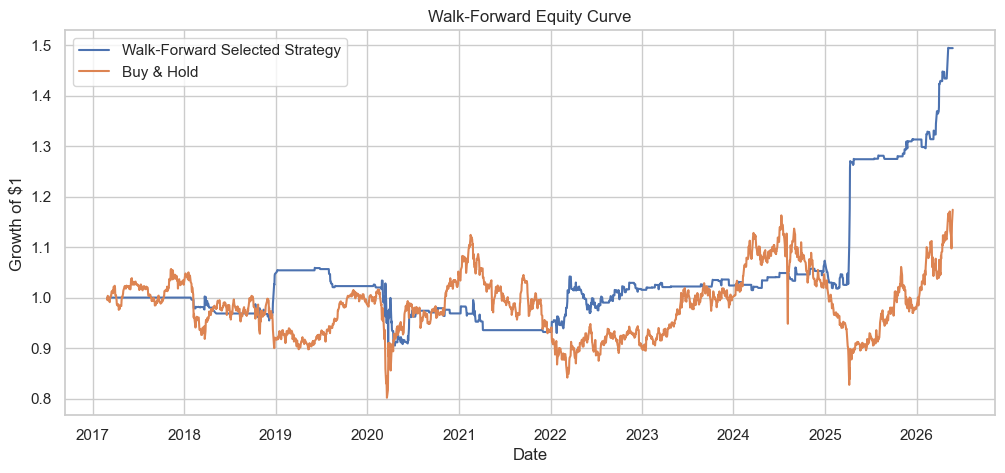

In [29]:
wf_plot = wf_results.copy()
wf_plot["strategy_equity"] = (1 + wf_plot["strategy_return"]).cumprod()
wf_plot["buy_hold_equity"] = (1 + wf_plot["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(wf_plot["japan_date"], wf_plot["strategy_equity"], label="Walk-Forward Selected Strategy")
plt.plot(wf_plot["japan_date"], wf_plot["buy_hold_equity"], label="Buy & Hold")
plt.title("Walk-Forward Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [30]:
wf_yearly = yearly_performance(wf_results, "japan_date")
wf_yearly

,year,strategy_return,benchmark_return,strategy_sharpe,benchmark_sharpe,strategy_max_drawdown,benchmark_max_drawdown
0,2017,0.000000,0.025488,NaN,0.400256,0.000000,-0.052154
1,2018,0.046682,-0.102238,0.629544,-0.813786,-0.047477,-0.142901
2,2019,-0.022874,0.071983,-1.233679,0.932471,-0.036311,-0.044433
3,2020,-0.052897,0.061043,-0.364280,0.343932,-0.124719,-0.211048
4,2021,-0.037996,-0.108932,-0.758894,-0.867993,-0.063654,-0.173268
5,2022,0.089642,-0.034898,0.987859,-0.279204,-0.069690,-0.105755
6,2023,0.008409,0.111610,0.303989,1.073795,-0.011965,-0.053230
7,2024,0.047970,0.034154,1.117396,0.176504,-0.016070,-0.184615
8,2025,0.223765,-0.055454,1.966015,-0.348314,-0.035201,-0.200142
9,2026,0.137806,0.200598,3.741583,2.970385,-0.013230,-0.067431


## Findings To Fill In

After running the full notebook, summarize:

1. Which strategy had the best exploratory Sharpe ratio?
2. Did long-short improve performance or mainly increase risk?
3. How sensitive was the long-only strategy to transaction costs?
4. Did the threshold strategies trade enough to be meaningful?
5. Which strategy was selected on validation data?
6. Did the selected strategy beat buy-and-hold on the untouched test set?
7. What is the most honest project conclusion?